# Лабораторная работа 6. Очистка и трансформация данных. pandas

Выполнил: Ашихмин Кирилл, группа P3124

## 1. Введение

Данные из реального мира почти никогда не готовы к анализу сразу: в них есть
пропуски, ошибки, выбросы и признаки в неудобном формате. По разным оценкам,
на подготовку данных уходит до 80% времени работы аналитика.

В этой работе мы пройдём полный цикл предобработки на классическом наборе
данных о пассажирах «Титаника» (Kaggle).

Нумерация разделов взята из задания. Между «Визуализациями» и «Заключением»
добавлен раздел 19 с метриками качества очистки: он требовался отдельным
пунктом, но в списке разделов его не было, поэтому дальше нумерация сдвинута
на единицу.

Основные понятия:

* Предобработка данных — подготовка данных к анализу.
* Очистка данных — устранение ошибок и пропусков.
* Трансформация данных — преобразование данных к виду, удобному для
  анализа и обучения моделей.
* pandas — основная библиотека Python для работы с табличными данными.

## 2. Цель работы

Освоить методы очистки и трансформации данных с использованием библиотеки
pandas на примере реальных данных из Kaggle.

## 3. Описание набора данных

Набор `train.csv` содержит 891 строку и 12 столбцов.

| Столбец | Описание |
|---|---|
| PassengerId | идентификатор пассажира |
| Survived | выжил ли пассажир (0 — нет, 1 — да) |
| Pclass | класс билета (1, 2, 3) |
| Name | имя |
| Sex | пол |
| Age | возраст |
| SibSp | количество братьев/сестёр/супругов на борту |
| Parch | количество родителей/детей на борту |
| Ticket | номер билета |
| Fare | стоимость билета |
| Cabin | номер каюты |
| Embarked | порт посадки (C — Шербур, Q — Квинстаун, S — Саутгемптон) |

Целевая переменная — Survived.

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')

# Чтобы pandas показывал все столбцы, а не сокращал их многоточием.
pd.set_option('display.max_columns', None)

# Локально датасет лежит в data/train.csv. В Colab этой папки нет,
# поэтому берём ту же таблицу по прямой ссылке: 891 строка, те же
# 12 столбцов, значения совпадают побайтно.
DATA_PATH = 'data/train.csv'
DATA_URL = ('https://raw.githubusercontent.com/datasciencedojo/'
            'datasets/master/titanic.csv')
DATA_SOURCE = DATA_PATH if os.path.exists(DATA_PATH) else DATA_URL

data = pd.read_csv(DATA_SOURCE)
print('Размер таблицы:', data.shape)

Размер таблицы: (891, 12)


## 4. Первичный анализ

### 4.1. Первые 10 строк

In [2]:
data.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


### 4.2. Типы данных каждого столбца

`info()` показывает сразу и тип столбца, и количество непустых значений —
по нему уже видно, где есть пропуски.

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


### 4.3. Количество пропусков в каждом столбце

`isnull()` возвращает таблицу из True/False, а `sum()` складывает их по
столбцам: True считается за 1, False — за 0. Так мы получаем число пропусков.

In [4]:
missing_count = data.isnull().sum()
missing_percent = (missing_count / len(data) * 100).round(2)

missing_report = pd.DataFrame({
    'Пропусков': missing_count,
    'Процент, %': missing_percent,
})
missing_report[missing_report['Пропусков'] > 0]

,Пропусков,"Процент, %"
Age,177,19.87
Cabin,687,77.10
Embarked,2,0.22


## 5. Статистика датафрейма

`describe()` считает статистики только для числовых столбцов. Транспонируем
результат (`.T`), чтобы признаки были строками — так таблицу удобнее читать.

In [5]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


### 5.1. Гистограммы распределения числовых признаков

Гистограмма показывает, как часто встречаются те или иные значения.
По ней сразу видно и форму распределения, и наличие выбросов.

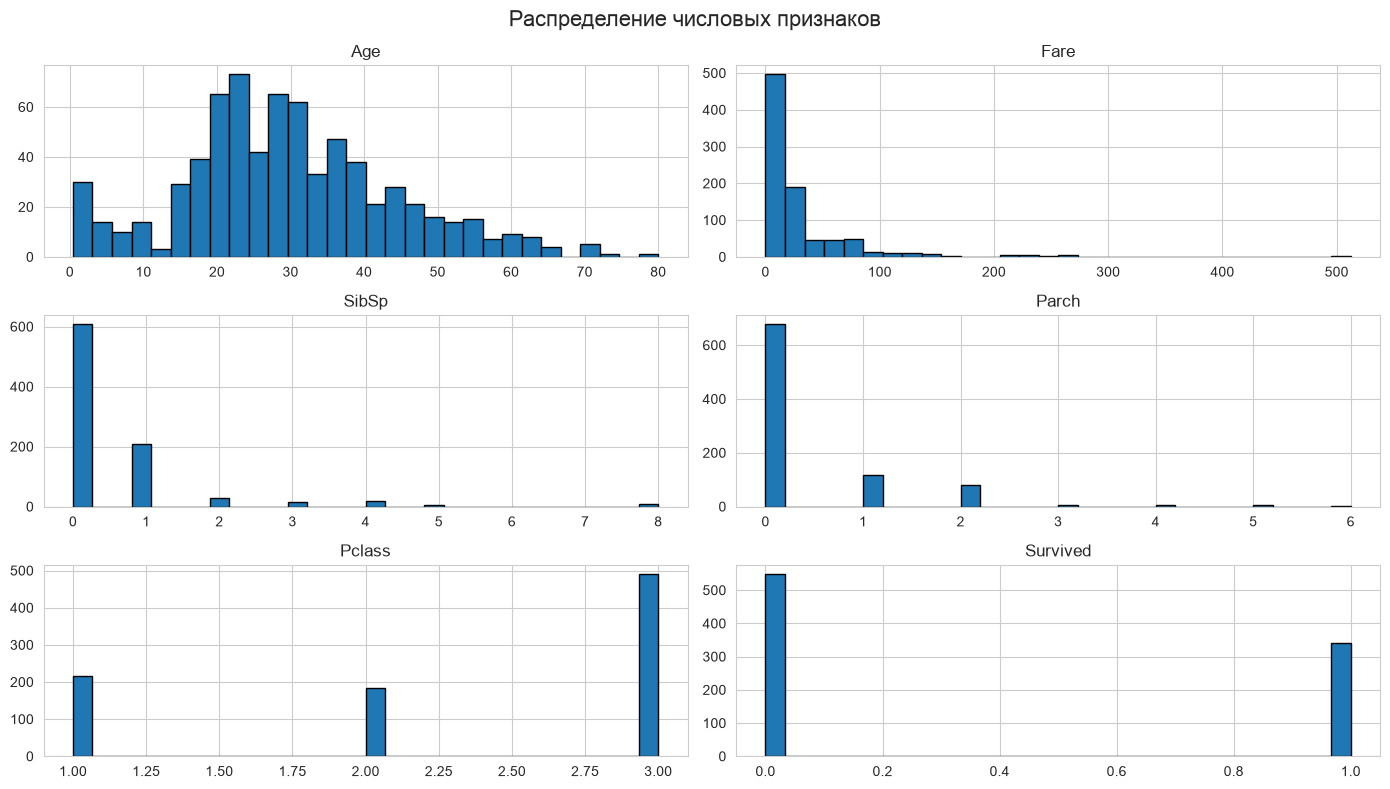

In [6]:
numeric_columns = ['Age', 'Fare', 'SibSp', 'Parch', 'Pclass', 'Survived']

data[numeric_columns].hist(figsize=(14, 8), bins=30, edgecolor='black')
plt.suptitle('Распределение числовых признаков', fontsize=16)
plt.tight_layout()
plt.show()

## 6. Визуализация пропусков

На тепловой карте светлые полосы — это пропуски. Сразу видно, что `Cabin`
пуст почти целиком, у `Age` пропуски разбросаны по всей таблице, а у
`Embarked` их всего два.

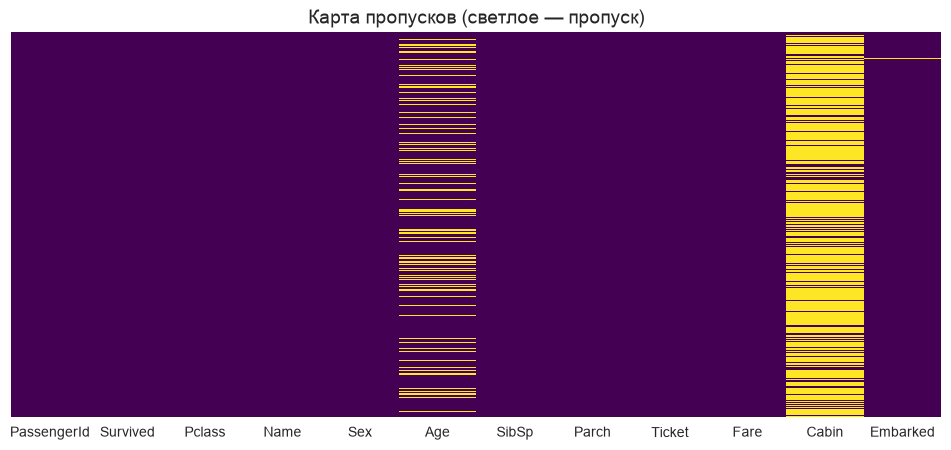

In [7]:
plt.figure(figsize=(12, 5))
sns.heatmap(data.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Карта пропусков (светлое — пропуск)', fontsize=14)
plt.show()

## 7. Обработка пропусков

### 7.1. Столбцы с пропусками

Пропуски есть в трёх столбцах:

| Столбец | Пропусков | Доля | Что делаем |
|---|---|---|---|
| Age | 177 | 19.9% | заполняем медианой |
| Cabin | 687 | 77.1% | создаём признак «палуба» из первой буквы |
| Embarked | 2 | 0.2% | заполняем модой |

## 8. Методы заполнения

### 8.1. Age: среднее и медиана

Сравним два варианта заполнения.

In [8]:
age_mean = data['Age'].mean()
age_median = data['Age'].median()

print(f'Среднее значение возраста:  {age_mean:.2f}')
print(f'Медианное значение возраста: {age_median:.2f}')
print(f'Асимметрия распределения (skew): {data["Age"].skew():.2f}')

Среднее значение возраста:  29.70
Медианное значение возраста: 28.00
Асимметрия распределения (skew): 0.39


Почему выбираем медиану, а не среднее.

Медиана — это значение, которое делит выборку пополам. В отличие от среднего,
она устойчива к выбросам: если в данных появится один пассажир 200 лет,
среднее заметно сдвинется, а медиана не изменится вообще.

У распределения возраста положительная асимметрия (правый «хвост» из пожилых
пассажиров), поэтому среднее немного завышено относительно типичного возраста.
Заполнение медианой меньше искажает исходное распределение.

In [9]:
data['Age'] = data['Age'].fillna(age_median)

print('Пропусков в Age после заполнения:', data['Age'].isnull().sum())

Пропусков в Age после заполнения: 0


### 8.2. Новый признак Age_group

Разобьём возраст на осмысленные категории. `pd.cut` делит числовой столбец на
интервалы по заданным границам и подписывает их.

In [10]:
age_bins = [0, 12, 18, 35, 60, 100]
age_labels = ['Ребёнок', 'Подросток', 'Молодой', 'Средний возраст', 'Пожилой']

data['Age_group'] = pd.cut(data['Age'], bins=age_bins, labels=age_labels)

data['Age_group'].value_counts().sort_index()

Age_group
Ребёнок             69
Подросток           70
Молодой            535
Средний возраст    195
Пожилой             22
Name: count, dtype: int64

### 8.3. Embarked: заполнение модой

Мода — самое частое значение. Для категориального признака это
единственный разумный вариант заполнения: среднее или медиану у названия порта
посчитать нельзя.

`mode()` возвращает Series (мод может быть несколько), поэтому берём первый
элемент через `[0]`.

In [11]:
embarked_mode = data['Embarked'].mode()[0]
print('Наиболее частый порт посадки:', embarked_mode)
print(data['Embarked'].value_counts().to_string())

data['Embarked'] = data['Embarked'].fillna(embarked_mode)
print('\nПропусков в Embarked после заполнения:', data['Embarked'].isnull().sum())

Наиболее частый порт посадки: S
Embarked
S    644
C    168
Q     77

Пропусков в Embarked после заполнения: 0


### 8.4. Cabin: удалять или преобразовывать?

В `Cabin` пропущено 77% значений. Заполнять такой столбец бессмысленно — мы
придумаем данные за три четверти пассажиров.

Но сам факт наличия номера каюты — это информация: каюты записаны в
основном у пассажиров первого класса. Поэтому вместо удаления сделаем два
новых признака:

* `Deck` — первая буква номера каюты (палуба), для пропусков ставим `'Unknown'`;
* `Has_cabin` — 1, если номер каюты известен, иначе 0.

Исходный столбец `Cabin` после этого удаляем: номер конкретной каюты
(например, `C85`) почти уникален и для анализа бесполезен.

In [12]:
# str[0] берёт первый символ строки; для пропусков результат тоже будет пропуском.
data['Deck'] = data['Cabin'].str[0].fillna('Unknown')
data['Has_cabin'] = data['Cabin'].notna().astype(int)

print(data['Deck'].value_counts().to_string())
print('\nДоля пассажиров с известной каютой по классам:')
print(data.groupby('Pclass')['Has_cabin'].mean().round(3).to_string())

Deck
Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1

Доля пассажиров с известной каютой по классам:
Pclass
1    0.815
2    0.087
3    0.024


In [13]:
# Удаляем исходный Cabin — он больше не нужен.
data = data.drop('Cabin', axis=1)

print('Столбцы после удаления Cabin:')
print(list(data.columns))

Столбцы после удаления Cabin:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked', 'Age_group', 'Deck', 'Has_cabin']


## 9. Результаты обработки пропусков

In [14]:
print('Пропусков осталось:')
print(data.isnull().sum().to_string())

Пропусков осталось:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Age_group      0
Deck           0
Has_cabin      0


## 10. Трансформация данных

## 11. Созданные признаки

## 12. Преобразования типов

### 12.1. Pclass — из числа в категорию

`Pclass` записан числами 1, 2, 3, но это не количественный признак:
третий класс не «в три раза больше» первого, это просто метка. Чтобы не
вводить модель в заблуждение, переведём его в строковые обозначения
(1 → F, 2 → S, 3 → T) и в тип `category`.

Тип `category` в pandas хранит не сами строки, а числовые коды и словарь
уникальных значений — это экономит память и ускоряет группировки.

In [15]:
pclass_mapping = {1: 'F', 2: 'S', 3: 'T'}

data['Pclass'] = data['Pclass'].map(pclass_mapping).astype('category')

print('Тип столбца Pclass:', data['Pclass'].dtype)
print(data['Pclass'].value_counts().to_string())

Тип столбца Pclass: category
Pclass
T    491
F    216
S    184


### 12.2. Title — обращение из имени

Имена записаны в формате `Фамилия, Обращение. Имя` — например,
`Braund, Mr. Owen Harris`. Обращение (Mr, Mrs, Miss) несёт информацию о поле,
возрасте и социальном статусе.

Достанем его регулярным выражением: ищем группу букв между пробелом и точкой.

In [16]:
# ' ([A-Za-z]+)\.' — пробел, затем группа из букв, затем точка.
# В скобках — то, что мы хотим извлечь.
data['Title'] = data['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

data['Title'].value_counts().to_string()

'Title\nMr          517\nMiss        182\nMrs         125\nMaster       40\nDr            7\nRev           6\nMajor         2\nMlle          2\nCol           2\nDon           1\nMme           1\nMs            1\nLady          1\nSir           1\nCapt          1\nCountess      1\nJonkheer      1'

In [17]:
# Редких обращений много, но каждое встречается 1-2 раза.
# Объединим их в одну группу 'Rare', а варианты написания приведём к общему виду.
data['Title'] = data['Title'].replace(['Mlle', 'Ms'], 'Miss')
data['Title'] = data['Title'].replace('Mme', 'Mrs')

common_titles = ['Mr', 'Mrs', 'Miss', 'Master']
data['Title'] = data['Title'].where(data['Title'].isin(common_titles), 'Rare')

print(data['Title'].value_counts().to_string())

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23


### 12.3. Sex — в числовой формат

Модели машинного обучения работают с числами, поэтому переведём пол в 0/1.

In [18]:
data['Sex'] = data['Sex'].map({'male': 0, 'female': 1})

print(data['Sex'].value_counts().to_string())
print('\n0 — мужчина, 1 — женщина')

Sex
0    577
1    314

0 — мужчина, 1 — женщина


### 12.4. FamilySize и IsAlone

`SibSp` (братья/сёстры/супруги) и `Parch` (родители/дети) по отдельности мало
что говорят. Сложим их и добавим единицу (самого пассажира) — получим размер
семьи на борту.

In [19]:
data['FamilySize'] = data['SibSp'] + data['Parch'] + 1
data['IsAlone'] = (data['FamilySize'] == 1).astype(int)

print(data['FamilySize'].value_counts().sort_index().to_string())
print('\nПутешествовали в одиночку:', data['IsAlone'].sum(), 'человек')

FamilySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7

Путешествовали в одиночку: 537 человек


Созданные признаки — сводка:

| Признак | Как получен | Зачем |
|---|---|---|
| `Age_group` | `pd.cut` по возрасту | группы вместо непрерывного значения |
| `Deck` | первая буква `Cabin` | палуба вместо номера каюты |
| `Has_cabin` | есть ли `Cabin` | косвенный признак достатка |
| `Title` | регулярное выражение по `Name` | статус, пол, возраст |
| `FamilySize` | `SibSp + Parch + 1` | размер семьи на борту |
| `IsAlone` | `FamilySize == 1` | путешествовал один или нет |

## 13. Обработка выбросов

## 14. Выявленные выбросы

### 14.1. Boxplot для Fare

Boxplot («ящик с усами») устроен так: прямоугольник охватывает от 25-го до
75-го перцентиля, линия внутри — медиана, «усы» тянутся на 1.5 межквартильных
размаха, а всё, что за ними — точки-выбросы.

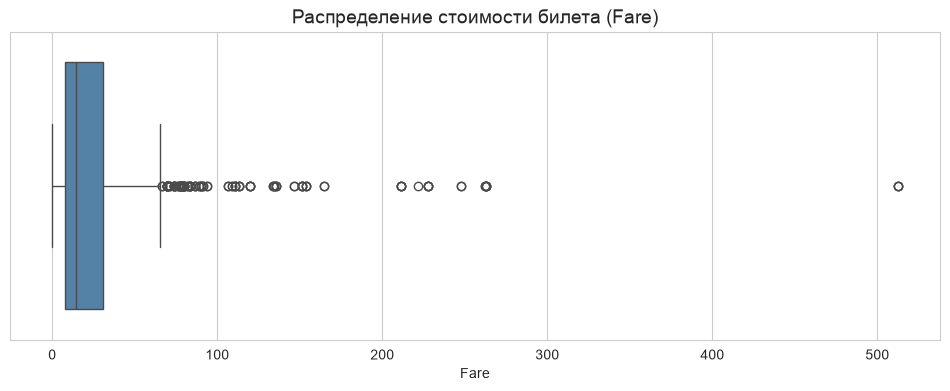

In [20]:
plt.figure(figsize=(12, 4))
sns.boxplot(x=data['Fare'], color='steelblue')
plt.title('Распределение стоимости билета (Fare)', fontsize=14)
plt.show()

### 14.2. Выбросы методом IQR

IQR (Interquartile Range, межквартильный размах) — это разница между 75-м
и 25-м перцентилями. Классическое правило: выбросом считается значение,
выходящее за границы

`[Q1 - 1.5 * IQR, Q3 + 1.5 * IQR]`

In [21]:
q1 = data['Fare'].quantile(0.25)
q3 = data['Fare'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = data[(data['Fare'] < lower_bound) | (data['Fare'] > upper_bound)]

print(f'Q1 = {q1:.2f}, Q3 = {q3:.2f}, IQR = {iqr:.2f}')
print(f'Границы: [{lower_bound:.2f}, {upper_bound:.2f}]')
print(f'Выбросов: {len(outliers)} из {len(data)} ({len(outliers) / len(data) * 100:.1f}%)')
print(f'Максимальная стоимость билета: {data["Fare"].max():.2f}')

Q1 = 7.91, Q3 = 31.00, IQR = 23.09
Границы: [-26.72, 65.63]
Выбросов: 116 из 891 (13.0%)
Максимальная стоимость билета: 512.33


Важный нюанс. Формально выбросов 116 (13%) — это очень много. Но если
посмотреть, кто это, окажется, что почти все они — пассажиры первого класса с
дорогими билетами. Это не ошибки в данных, а реальные значения.

Поэтому удалять такие строки нельзя: мы потеряли бы значительную часть первого
класса и исказили анализ выживаемости. Вместо удаления применим
винсоризацию — ограничим экстремальные значения, сохранив сами строки.

In [22]:
print('Распределение выбросов по классам:')
print(outliers['Pclass'].value_counts().to_string())

Распределение выбросов по классам:
Pclass
F    104
T      7
S      5


### 14.3. Визуализация распределения Age

Смотрим на гистограмму и boxplot рядом: гистограмма показывает форму
распределения, boxplot — границы и выбросы.

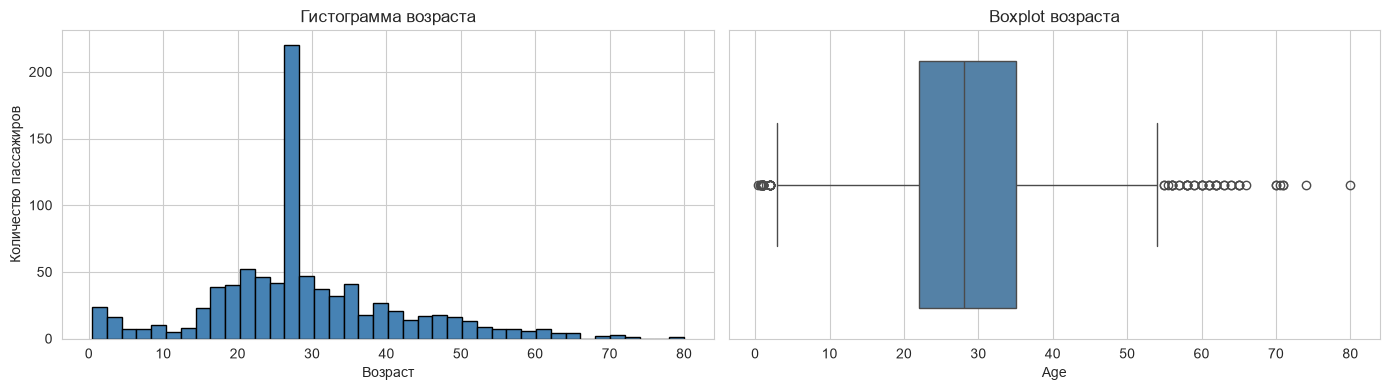

In [23]:
figure, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(data['Age'], bins=40, color='steelblue', edgecolor='black')
axes[0].set_title('Гистограмма возраста')
axes[0].set_xlabel('Возраст')
axes[0].set_ylabel('Количество пассажиров')

sns.boxplot(x=data['Age'], ax=axes[1], color='steelblue')
axes[1].set_title('Boxplot возраста')

plt.tight_layout()
plt.show()

На гистограмме виден резкий пик около 28 лет — это следствие заполнения
177 пропусков медианой. Так всегда происходит при заполнении константой:
распределение искусственно «сжимается» к одному значению. Это плата за
сохранение строк — альтернативой было бы удалить 20% выборки.

## 15. Методы обработки

### 15.1. Винсоризация Fare

Винсоризация — замена экстремальных значений на значения перцентилей.
В отличие от удаления, строки сохраняются, теряется только «хвост»
распределения.

Ограничим Fare 5-м и 95-м перцентилями.

In [24]:
fare_lower = data['Fare'].quantile(0.05)
fare_upper = data['Fare'].quantile(0.95)

data['Fare_winsorized'] = data['Fare'].clip(lower=fare_lower, upper=fare_upper)

print(f'5-й перцентиль:  {fare_lower:.2f}')
print(f'95-й перцентиль: {fare_upper:.2f}')
print()
print('До винсоризации: ', data['Fare'].describe()[['mean', 'std', 'max']].round(2).to_dict())
print('После:           ', data['Fare_winsorized'].describe()[['mean', 'std', 'max']].round(2).to_dict())

5-й перцентиль:  7.22
95-й перцентиль: 112.08

До винсоризации:  {'mean': 32.2, 'std': 49.69, 'max': 512.33}
После:            {'mean': 27.86, 'std': 29.11, 'max': 112.08}


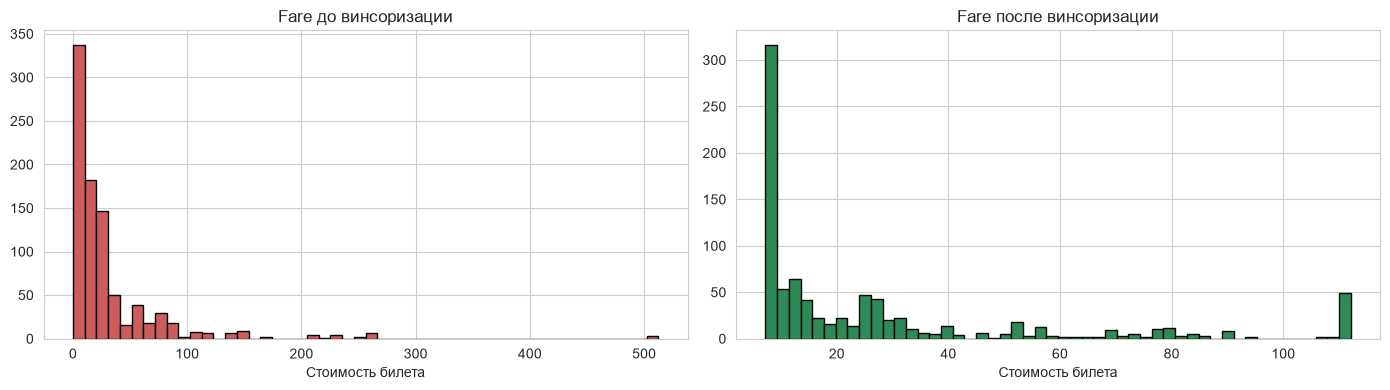

In [25]:
figure, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(data['Fare'], bins=50, color='indianred', edgecolor='black')
axes[0].set_title('Fare до винсоризации')
axes[0].set_xlabel('Стоимость билета')

axes[1].hist(data['Fare_winsorized'], bins=50, color='seagreen', edgecolor='black')
axes[1].set_title('Fare после винсоризации')
axes[1].set_xlabel('Стоимость билета')

plt.tight_layout()
plt.show()

### 15.2. Ограничение Age 95-м перцентилем

Для возраста задание требует заменить экстремальные значения на 95-й
перцентиль, то есть обрезать только сверху.

In [26]:
age_95 = data['Age'].quantile(0.95)

data['Age_capped'] = data['Age'].clip(upper=age_95)

print(f'95-й перцентиль возраста: {age_95:.2f}')
print(f'Максимальный возраст до:    {data["Age"].max():.1f}')
print(f'Максимальный возраст после: {data["Age_capped"].max():.1f}')
print(f'Изменено значений: {(data["Age"] > age_95).sum()}')

95-й перцентиль возраста: 54.00
Максимальный возраст до:    80.0
Максимальный возраст после: 54.0
Изменено значений: 42


## 16. Агрегация и анализ

## 17. Сводные статистики

### 17.1. Среднее выживание по классам

Так как `Survived` принимает значения 0 и 1, среднее по этому столбцу
равно доле выживших. Это удобный приём: не нужно отдельно считать
количество и делить.

In [27]:
survival_by_class = data.groupby('Pclass', observed=True)['Survived'].agg(['mean', 'count'])
survival_by_class.columns = ['Доля выживших', 'Всего пассажиров']
survival_by_class.round(3)

,Доля выживших,Всего пассажиров
Pclass,,
F,0.630,216
S,0.473,184
T,0.242,491


### 17.2. Группировка по Pclass и Sex

Группировка сразу по двум признакам показывает, как они действуют совместно.

In [28]:
survival_by_class_sex = data.groupby(['Pclass', 'Sex'], observed=True)['Survived'].mean()
survival_by_class_sex.round(3)

Pclass  Sex
F       0      0.369
        1      0.968
S       0      0.157
        1      0.921
T       0      0.135
        1      0.500
Name: Survived, dtype: float64

### 17.3. Медианный возраст по портам посадки

In [29]:
age_by_port = data.groupby('Embarked')['Age'].agg(['median', 'mean', 'count'])
age_by_port.columns = ['Медианный возраст', 'Средний возраст', 'Пассажиров']
age_by_port.round(2)

,Медианный возраст,Средний возраст,Пассажиров
Embarked,,,
C,28.0,30.18,168
Q,28.0,28.03,77
S,28.0,29.31,646


### 17.4. Сводная таблица по новым признакам

`pivot_table` строит таблицу, где один признак идёт по строкам, другой — по
столбцам, а в ячейках — агрегированное значение (по умолчанию среднее).

In [30]:
pivot_title_class = pd.pivot_table(
    data,
    values='Survived',
    index='Title',
    columns='Pclass',
    aggfunc='mean',
    observed=True,
)
pivot_title_class.round(3)

Pclass,F,S,T
Title,,,
Master,1.000,1.000,0.393
Miss,0.958,0.943,0.500
Mr,0.346,0.088,0.113
Mrs,0.977,0.902,0.500
Rare,0.533,0.000,NaN


In [31]:
pivot_family = pd.pivot_table(
    data,
    values='Survived',
    index='Age_group',
    columns='IsAlone',
    aggfunc='mean',
    observed=True,
)
pivot_family.columns = ['С семьёй', 'Один']
pivot_family.round(3)

,С семьёй,Один
Age_group,,
Ребёнок,0.582,0.500
Подросток,0.500,0.353
Молодой,0.481,0.300
Средний возраст,0.506,0.311
Пожилой,0.250,0.222


### 17.5. Сохранение очищенных данных

In [33]:
data.to_csv('titanic_cleaned.csv', index=False)

print('Файл titanic_cleaned.csv сохранён.')
print('Размер итоговой таблицы:', data.shape)
print('\nСтолбцы:')
print(list(data.columns))

Файл titanic_cleaned.csv сохранён.
Размер итоговой таблицы: (891, 19)

Столбцы:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked', 'Age_group', 'Deck', 'Has_cabin', 'Title', 'FamilySize', 'IsAlone', 'Fare_winsorized', 'Age_capped']


## 18. Визуализации

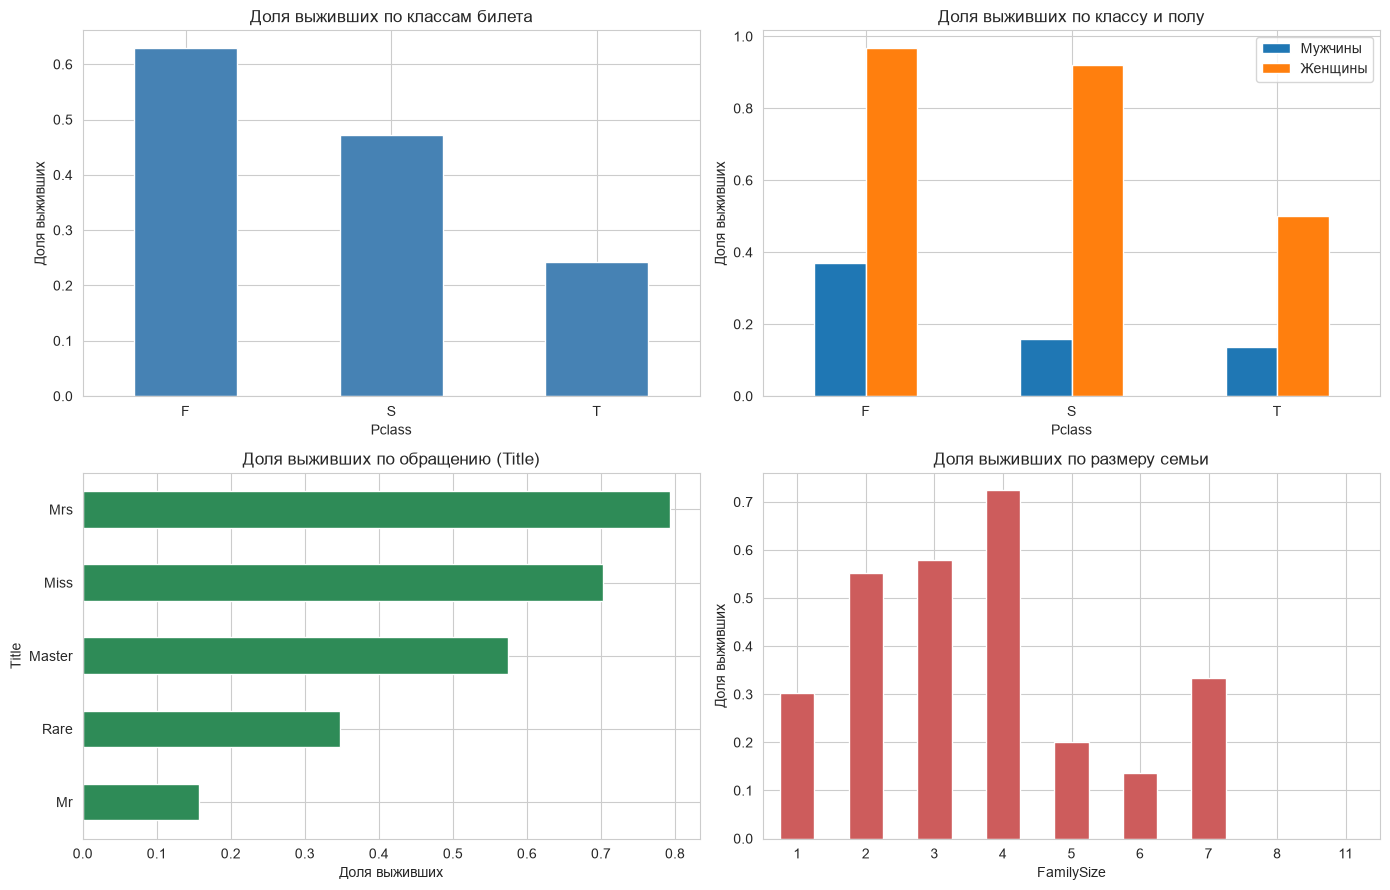

In [32]:
figure, axes = plt.subplots(2, 2, figsize=(14, 9))

# Выживаемость по классам
survival_by_class['Доля выживших'].plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Доля выживших по классам билета')
axes[0, 0].set_ylabel('Доля выживших')
axes[0, 0].tick_params(axis='x', rotation=0)

# Выживаемость по полу и классу
survival_by_class_sex.unstack().plot(kind='bar', ax=axes[0, 1])
axes[0, 1].set_title('Доля выживших по классу и полу')
axes[0, 1].set_ylabel('Доля выживших')
axes[0, 1].legend(['Мужчины', 'Женщины'])
axes[0, 1].tick_params(axis='x', rotation=0)

# Выживаемость по обращению
data.groupby('Title')['Survived'].mean().sort_values().plot(
    kind='barh', ax=axes[1, 0], color='seagreen')
axes[1, 0].set_title('Доля выживших по обращению (Title)')
axes[1, 0].set_xlabel('Доля выживших')

# Выживаемость по размеру семьи
data.groupby('FamilySize')['Survived'].mean().plot(
    kind='bar', ax=axes[1, 1], color='indianred')
axes[1, 1].set_title('Доля выживших по размеру семьи')
axes[1, 1].set_ylabel('Доля выживших')
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 19. Метрики качества очистки данных

### 19.1. Процент заполненных пропусков

In [34]:
original = pd.read_csv(DATA_SOURCE)

missing_before = original.isnull().sum().sum()
missing_after = data.isnull().sum().sum()

print(f'Пропусков было:  {missing_before}')
print(f'Пропусков стало: {missing_after}')
print(f'Заполнено: {(missing_before - missing_after) / missing_before * 100:.1f}%')

comparison = pd.DataFrame({
    'Было': original.isnull().sum(),
    'Стало': data.isnull().sum().reindex(original.columns),
})
# Cabin не заполнялся, а был преобразован в Deck / Has_cabin и удалён,
# поэтому в итоговой таблице его просто нет.
comparison['Стало'] = comparison['Стало'].apply(
    lambda value: 'столбец удалён' if pd.isna(value) else int(value))

comparison[comparison['Было'] > 0]

Пропусков было:  866
Пропусков стало: 0
Заполнено: 100.0%


,Было,Стало
Age,177,0
Cabin,687,столбец удалён
Embarked,2,0


### 19.2. Количество уникальных значений в категориальных признаках

In [35]:
categorical_columns = ['Pclass', 'Sex', 'Embarked', 'Title', 'Deck',
                       'Age_group', 'IsAlone', 'Has_cabin']

unique_report = pd.DataFrame({
    'Уникальных значений': [data[c].nunique() for c in categorical_columns],
    'Примеры': [', '.join(map(str, data[c].unique()[:5])) for c in categorical_columns],
}, index=categorical_columns)
unique_report

,Уникальных значений,Примеры
Pclass,3,"T, F, S"
Sex,2,"0, 1"
Embarked,3,"S, C, Q"
Title,5,"Mr, Mrs, Miss, Master, Rare"
Deck,9,"Unknown, C, E, G, D"
Age_group,5,"Молодой, Средний возраст, Ребёнок, Подросток, ..."
IsAlone,2,"0, 1"
Has_cabin,2,"0, 1"


### 19.3. Распределение значений после трансформации

In [36]:
for column in ['Pclass', 'Title', 'Age_group', 'IsAlone']:
    print(f'--- {column} ---')
    distribution = data[column].value_counts(normalize=True).sort_index()
    print((distribution * 100).round(1).to_string())
    print()

--- Pclass ---
Pclass
F    24.2
S    20.7
T    55.1

--- Title ---
Title
Master     4.5
Miss      20.8
Mr        58.0
Mrs       14.1
Rare       2.6

--- Age_group ---
Age_group
Ребёнок             7.7
Подросток           7.9
Молодой            60.0
Средний возраст    21.9
Пожилой             2.5

--- IsAlone ---
IsAlone
0    39.7
1    60.3



### 19.4. Корреляция между новыми признаками

Корреляция показывает, насколько два признака меняются согласованно.
Значение близко к +1 — растут вместе, близко к -1 — один растёт, другой падает,
около 0 — линейной связи нет.

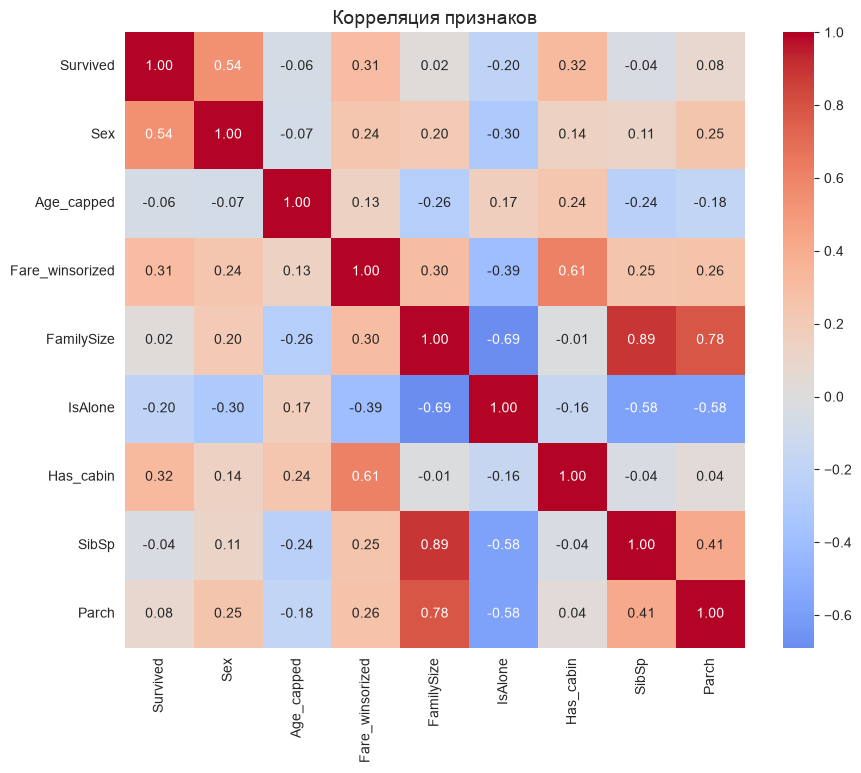

In [37]:
correlation_columns = ['Survived', 'Sex', 'Age_capped', 'Fare_winsorized',
                       'FamilySize', 'IsAlone', 'Has_cabin', 'SibSp', 'Parch']

correlation_matrix = data[correlation_columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Корреляция признаков', fontsize=14)
plt.show()

In [38]:
# Какие признаки сильнее всего связаны с выживаемостью.
correlation_matrix['Survived'].drop('Survived').sort_values(
    key=abs, ascending=False).round(3)

Sex                0.543
Has_cabin          0.317
Fare_winsorized    0.313
IsAlone           -0.203
Parch              0.082
Age_capped        -0.062
SibSp             -0.035
FamilySize         0.017
Name: Survived, dtype: float64

## 20. Заключение

Таблица из 891 строки и 12 столбцов приведена к виду, пригодному для обучения
модели: пропусков не осталось, категории закодированы, выбросы ограничены,
добавлено восемь производных признаков. Ниже сведены цифры и то, что по ходу
оказалось неочевидным.

## 21. Результаты работы

Обработано пропусков: 866 из 866.

| Столбец | Было пропусков | Метод | Стало |
|---|---|---|---|
| Age | 177 (19.9%) | заполнение медианой | 0 |
| Embarked | 2 (0.2%) | заполнение модой | 0 |
| Cabin | 687 (77.1%) | преобразован в `Deck` и `Has_cabin`, затем удалён | 0 |

Создано 8 признаков: `Age_group`, `Deck`, `Has_cabin`, `Title`, `FamilySize`,
`IsAlone`, `Fare_winsorized`, `Age_capped`.

Типы: `Pclass` переведён в категориальный (F/S/T), `Sex` в числовой (0/1).

Выбросы: `Fare` винсоризован по 5-му и 95-му перцентилям, `Age` ограничен
95-м перцентилем.

Итоговая таблица сохранена в `titanic_cleaned.csv`.

## 22. Выводы

1. Способ заполнения пропуска зависит от типа признака. Для `Age` взята
медиана, она устойчива к выбросам. Для `Embarked` мода, потому что среднее у
названия порта не определено.

2. Заполнение константой искажает распределение. После подстановки медианы на
гистограмме `Age` вырос пик около 28 лет: 177 пассажиров получили одинаковый
возраст. Это плата за сохранённые 20% выборки, и при дальнейшем анализе про
неё надо помнить.

3. Столбец с 77% пропусков не обязательно выбрасывать. Заполнять `Cabin` было
нельзя, иначе мы придумали бы данные за три четверти пассажиров. Но сам факт
наличия каюты оказался информативным: в первом классе номер известен у
значительной части пассажиров, в третьем почти ни у кого. Отсутствие данных
тоже бывает признаком.

4. Формальный выброс не всегда ошибка. IQR пометил 116 значений `Fare` (13%),
почти все они принадлежат первому классу. Это настоящие дорогие билеты,
удаление строк исказило бы выборку. Поэтому применена винсоризация: значения
ограничены, строки сохранены.

5. Признак, собранный из двух исходных, показал то, чего не видно по
отдельности. `SibSp` и `Parch` с выживаемостью почти не связаны (корреляция
-0.035 и 0.082), а их сумма `FamilySize` даёт вот такую картину:

| Размер семьи | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 11 |
|---|---|---|---|---|---|---|---|---|---|
| Доля выживших | 0.30 | 0.55 | 0.58 | 0.72 | 0.20 | 0.14 | 0.33 | 0.00 | 0.00 |
| Пассажиров | 537 | 161 | 102 | 29 | 15 | 22 | 12 | 6 | 7 |

Лучше всего дела у семей из 2-4 человек, хуже всего у одиночек и у больших
семей. Провал не совсем ровный: на размере 7 доля подскакивает до 0.33, но там
всего 12 человек, и одна спасшаяся семья меняет цифру целиком. Начиная с
размера 4 в каждой группе меньше 30 наблюдений, так что доверять этим долям по
отдельности нельзя, видна только общая форма.

Любопытно, что линейная корреляция `FamilySize` с `Survived` равна 0.017, то
есть по корреляции признак выглядит бесполезным. Корреляция ловит только
линейную связь, а зависимость здесь горбом. Одного коэффициента мало, надо
смотреть на разбивку.

6. Числа в категориальном столбце легко принять за количества. `Pclass`
записан как 1/2/3, но третий класс не «втрое больше» первого. Перевод в
категориальный тип защищает от такой интерпретации при обучении.

7. Сильнее всего на выживаемость влияет пол: корреляция `Sex` с `Survived`
заметно выше остальных. То же видно в разбивке по обращениям, у `Mrs` и `Miss`
доля выживших намного выше, чем у `Mr`.
